# Construct global cumulative co2 flux time series

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Set params

In [42]:
#stat = 'integral'#'integral'#'mean'
#freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['fgco2'] # 'tas','tos',
models = ['IPSL-CM6-ESMCO2']#,'GFDL-ESM2M','NorESM2-LM','UKESM1-2','EC-Earth3-ESM-1']#['GISSE2.1-G-CC2'].   #]#, ]#, # 
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1
root_dir = f'./../01_postprocessed_data/global_time_series'

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

In [43]:
#def convert_units(varia,stat,da):
#    if varia == 'fco2antt' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2 x s','kgC/m2/s x m2 x s']:
#        converter = 1 / 1000 / 1000 / 1000 / 1000
#        da_conv = da*converter
#        da_conv.attrs["units"] = r'PgC'
#    return da_conv

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter','dissic','fco2antt']:
            stat = 'integral'
        elif varia in ['co2mass']:
            stat = None
    else:
        stat = 'mean'
    return stat

def get_vert_stat(varia,default=True):
    if default == True:
        if varia in ['dissic']:
            vert_stat = 'integral'
        else:
            vert_stat = None
    else:
        vert_stat = None
    return vert_stat
    
def get_infix(varia,default=True):
    infix_base = 'vertical_'
    if default == True:
        if varia in ['dissic']:
            infix = infix_base+'integral_'
        else:
            infix = ''
    else:
        infix = ''
    return infix  

def get_suffix(varia,default=True):
    if default == True:
        if varia in ['fco2antt','nbp','fgco2']:
            suffix = '_cumulated'
        else:
            suffix = ''
    else:
        suffix = ''
    return suffix    

... saving under ./../01_postprocessed_data/global_time_series/fgco2/IPSL-CM6-ESMCO2/esm-piControl/r1i2p3f1/monthly/global_integral_cumulated/fgco2_IPSL-CM6-ESMCO2_esm-piControl_r1i2p3f1_global_integral_cumulated.nc
... saving under ./../01_postprocessed_data/global_time_series/fgco2/IPSL-CM6-ESMCO2/esm-up2p0/r1i2p3f1/monthly/global_integral_cumulated/fgco2_IPSL-CM6-ESMCO2_esm-up2p0_r1i2p3f1_global_integral_cumulated.nc
... saving under ./../01_postprocessed_data/global_time_series/fgco2/IPSL-CM6-ESMCO2/esm-up2p0-gwl2p0/r1i2p3f1/monthly/global_integral_cumulated/fgco2_IPSL-CM6-ESMCO2_esm-up2p0-gwl2p0_r1i2p3f1_global_integral_cumulated.nc
... saving under ./../01_postprocessed_data/global_time_series/fgco2/IPSL-CM6-ESMCO2/esm-up2p0-gwl4p0/r1i2p3f1/monthly/global_integral_cumulated/fgco2_IPSL-CM6-ESMCO2_esm-up2p0-gwl4p0_r1i2p3f1_global_integral_cumulated.nc
... saving under ./../01_postprocessed_data/global_time_series/fgco2/IPSL-CM6-ESMCO2/esm-up2p0-gwl2p0-50y-dn2p0/r1i2p3f1/monthly/glo

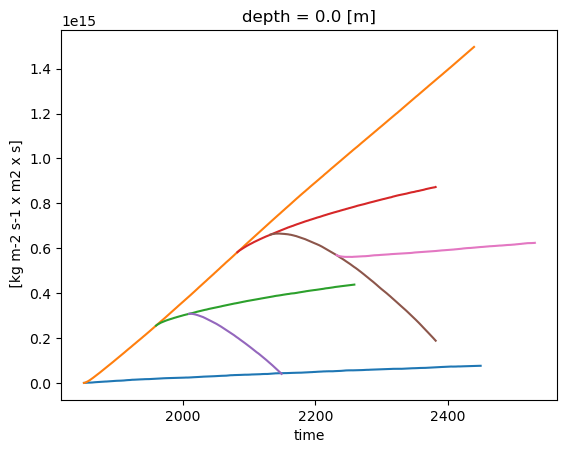

In [45]:
for varia in varias:
    stat = get_stat(varia)
    vert_stat = get_vert_stat(varia,default=True)
    infix = get_infix(varia,default=True)
    suffix = get_suffix(varia,default=True)
    #fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

    for mdx, model in enumerate(models):
        freq = get_freq_input(model)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()

        rc = RConcatenator(
            model=model,
            member=member,
            varia=varia,
            freq=freq,
            stat=stat,
            root_dir=root_dir,
        )

        for rdx, run in enumerate(runs):

            file_string = f'{root_dir}/{varia}/{model}/{run}/{member}/{freq}/{infix}global_{stat}/{varia}_{model}_{run}_{member}_{infix}global_{stat}.nc'

            if miniFuncs.is_available(file_string):

                da = rc.get_concatenated_da(run=run, ref_year=ref_year)

                #da.plot();plt.show()

                # integrate
                if da.size > 0:
                    da_int = TimeOperator.integrate_in_time(da)
                    #da_int = convert_units(varia, stat, da_int)

                # now from the integrated time series, only take the time slice corresponding to the respective run and save it as such
                da_ref = DFuncs.open_dataset(file_string)#xr.open_dataset(file_string,cftime)
                da_ref = TimeOperator.shift_time_axis_to_ref_year(model, da_ref, ref_year=ref_year)
                t0 = da_ref.time.min()
                t1 = da_ref.time.max()
                da_int = da_int.sel(time=slice(t0, t1))

                # shift this back to the "real" years
                rsy = pmods.get_model_dict('all')[model].rampup_start_year
                n = rsy - ref_year
                da_int = TimeOperator.shift_time_axis_by_n_years(da_int,n=n,set_to_start_of_months=False)
                da_int.plot()

                #print(da_int.time)

                save_dir = f'{root_dir}/{varia}/{model}/{run}/{member}/{freq}/{infix}global_{stat}_cumulated'
                os.makedirs(save_dir,exist_ok=True)
                save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_{infix}global_{stat}_cumulated.nc'
                print(f'... saving under {save_string}')
                da_int.to_dataset(name=f"{varia}_{infix}global_{stat}{suffix}").to_netcdf(save_string)#,encoding=encoding)


In [38]:
da_int

<xarray.DataArray (time: 3600)>
array([5.63258107e+14, 5.62950804e+14, 5.62290472e+14, ...,
       4.35713280e+14, 4.34547033e+14, 4.34040876e+14])
Coordinates:
  * time     (time) object 2232-01-16 12:00:00 ... 2531-12-16 12:00:00
Attributes:
    units:    kg m-2 s-1 x m2 x s